# 3 · What each component is (manuscript §3.1–3.2)

PCA of the pathway-score matrix, the component annotation, and the test of every
component against every recorded variable — biological and technical — with
Benjamini–Hochberg control over the whole grid (the attribution grid), followed by
the one-vs-rest test that names the component separating each diagnosis.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `analysis` importable from notebooks/

from analysis import notebook as nb
nb.setup()

working in sarcoma/


`submission/figures/figure1.png`

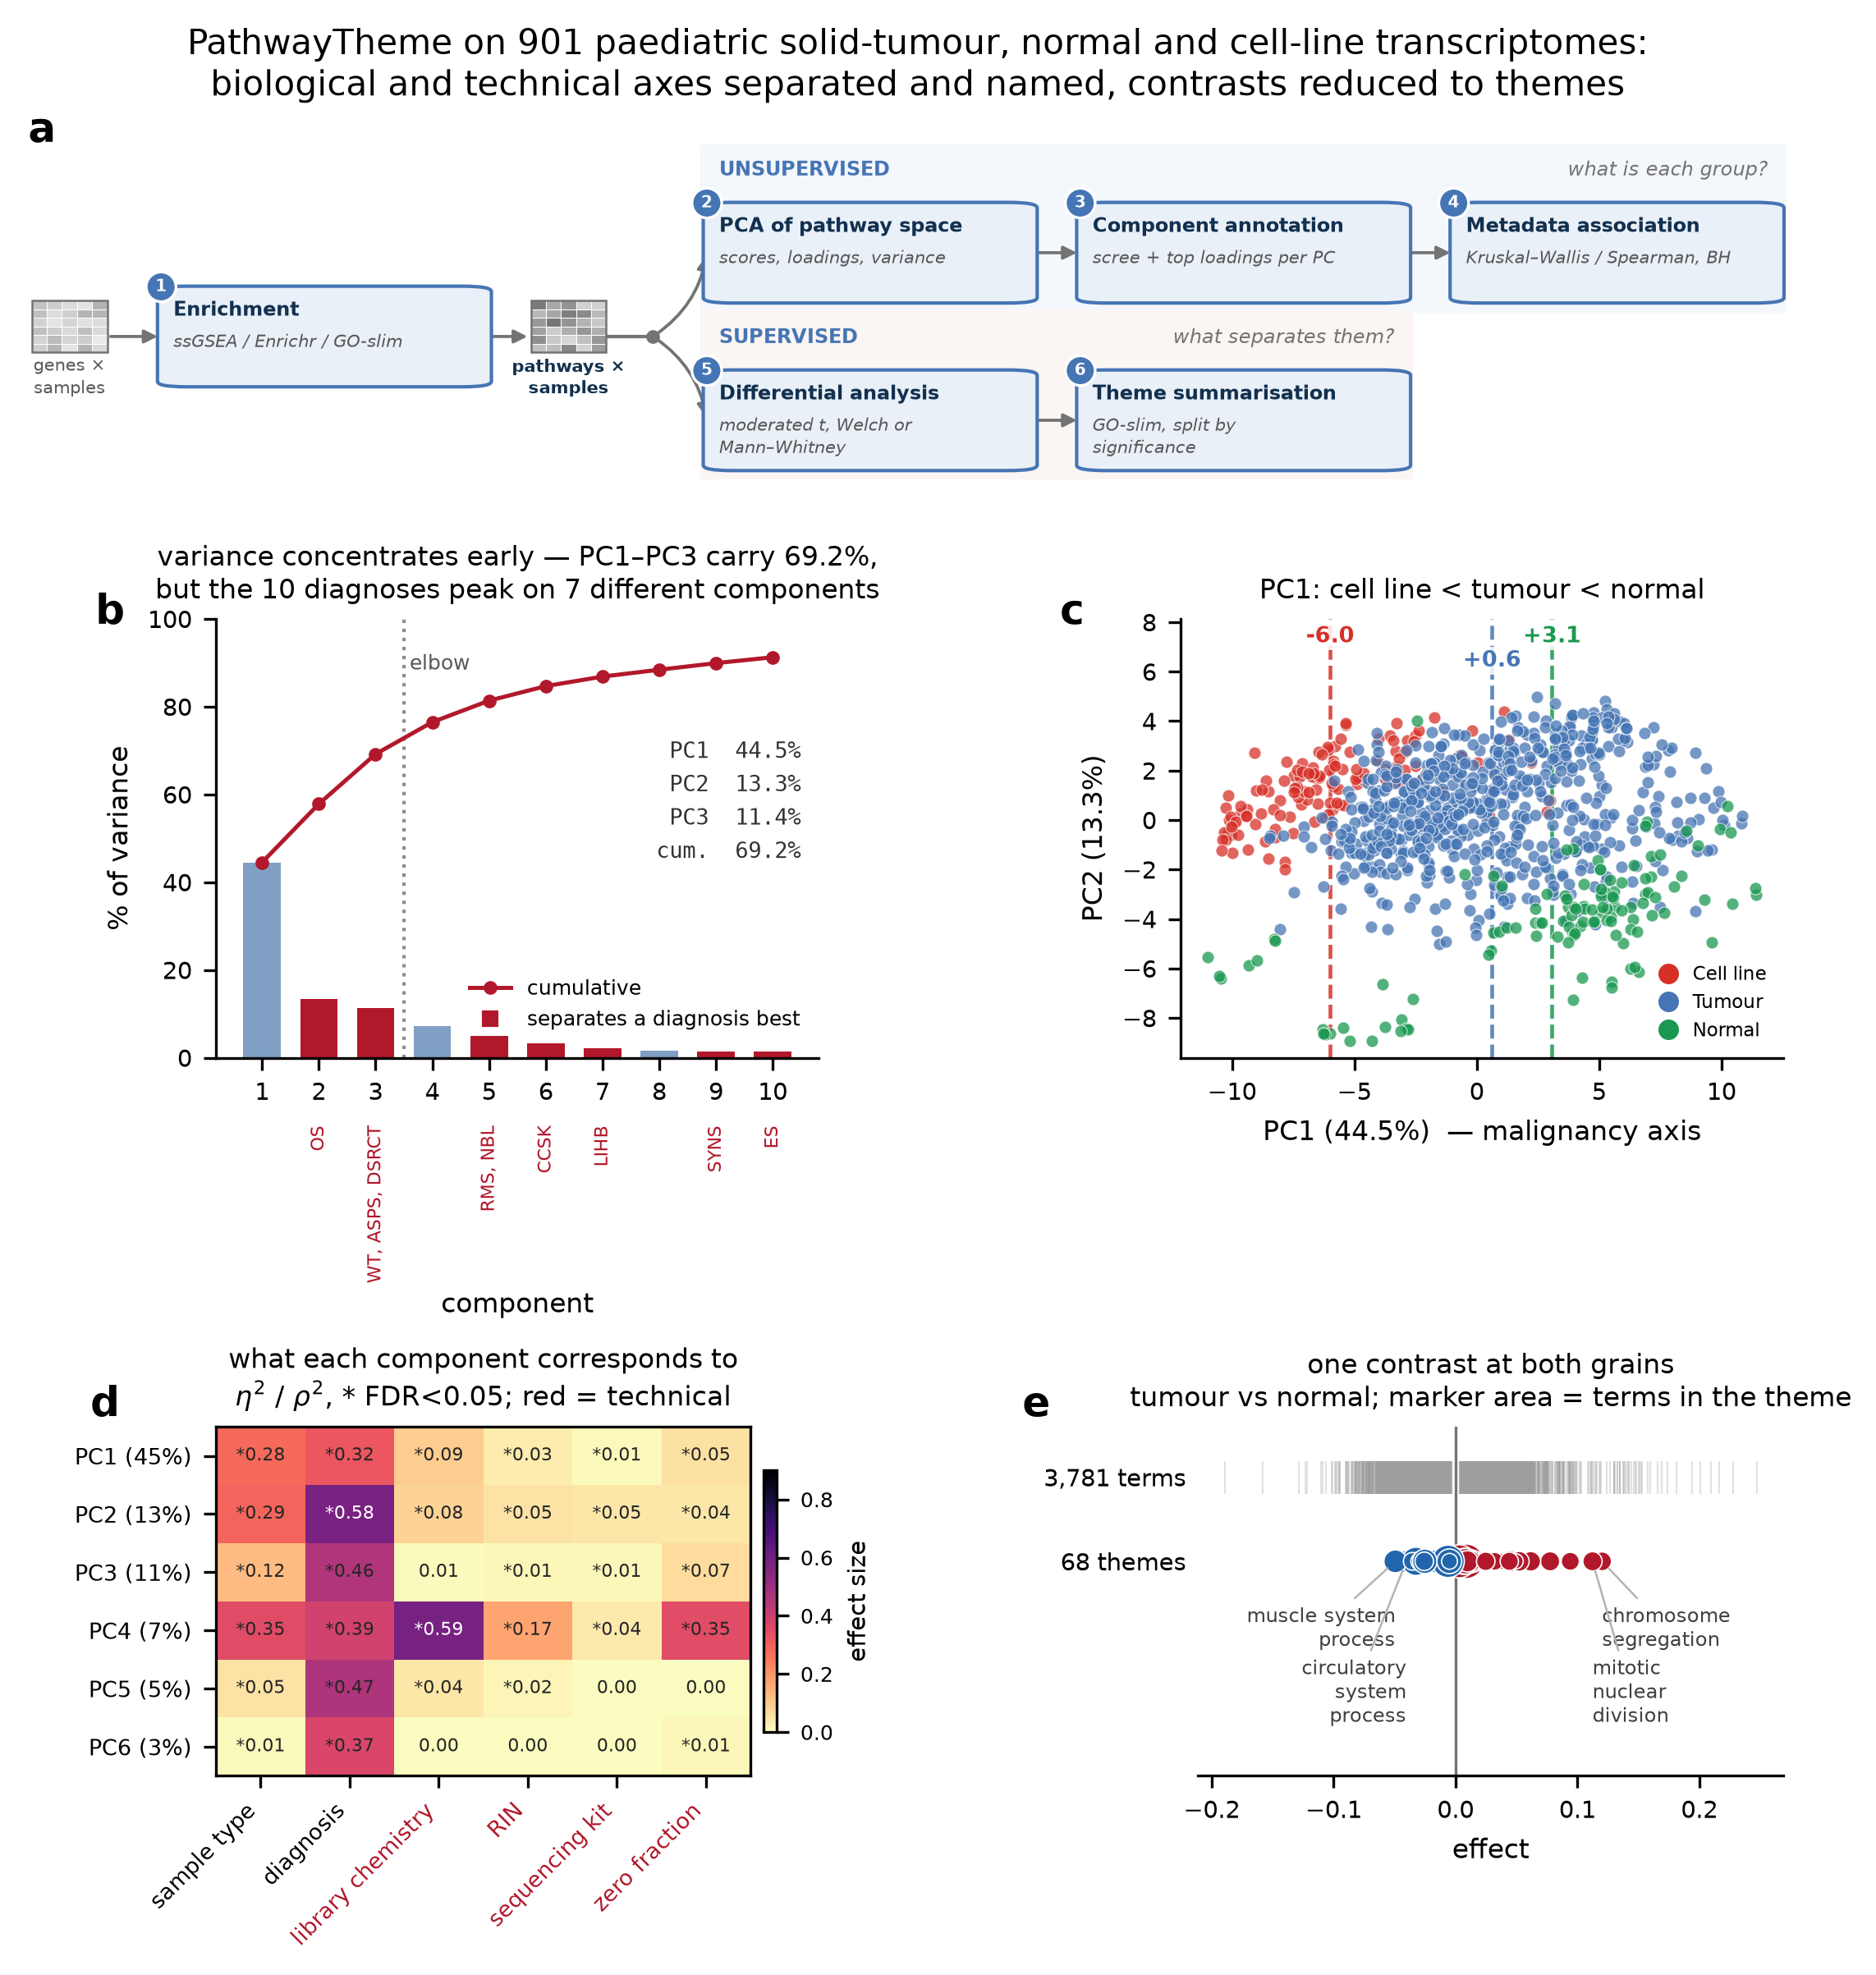

In [2]:
from analysis import figures

figures.figure1()
nb.show_figure("figure1")

**Attribution grids and one-vs-rest tests.** Table S3 (hallmark) and Table S4
(GO:BP) hold every component × variable test; Tables S8–S9 every level against the
rest; Table S7 the top loadings; Table S20 the best component per diagnosis in both
collections.

In [3]:
for t in (figures.table_s3, figures.table_s4, figures.table_s7,
          figures.table_s8, figures.table_s9, figures.table_s20):
    nb.show_table(t(), rows=5, name=t.__doc__.splitlines()[0])

**Table S3: metadata-by-component association tests, hallmark collection.** — 60 rows × 13 columns

,component,variable,kind,test,n,n_levels,statistic,effect,effect_name,p_value,top_level,fdr,significant
0,PC4,library_type,categorical,kruskal,901,4.0,528.725806,0.586093,eta_squared,2.838079e-114,ribozero,1.702847e-112,True
1,PC2,diagnosis,categorical,kruskal,777,14.0,456.589234,0.581375,eta_squared,2.376608e-89,OS,7.129824e-88,True
2,PC4,zero_fraction,continuous,spearman,901,NaN,0.591965,0.350423,rho_squared,2.687061e-86,NaN,5.374122e-85,True
3,PC5,diagnosis,categorical,kruskal,777,14.0,369.184380,0.466821,eta_squared,7.090019e-71,RMS,1.063503e-69,True
4,PC3,diagnosis,categorical,kruskal,777,14.0,364.062667,0.460108,eta_squared,8.504117e-70,LIHB,9.179460e-69,True


**Table S4: metadata-by-component association tests, GO:BP collection.** — 60 rows × 13 columns

,component,variable,kind,test,n,n_levels,statistic,effect,effect_name,p_value,top_level,fdr,significant
0,PC2,diagnosis,categorical,kruskal,777,14.0,607.943647,0.779743,eta_squared,1.552321e-121,NBL,9.313928e-120,True
1,PC4,library_type,categorical,kruskal,901,4.0,435.268684,0.481905,eta_squared,5.068966e-94,ribozero,1.520690e-92,True
2,PC7,diagnosis,categorical,kruskal,777,14.0,456.516939,0.581280,eta_squared,2.461953e-89,LIHB,4.923906e-88,True
3,PC4,sample_type,categorical,kruskal,901,3.0,370.833729,0.410728,eta_squared,2.981803e-81,NORMAL,4.472705e-80,True
4,PC6,diagnosis,categorical,kruskal,777,14.0,403.926700,0.512355,eta_squared,3.312386e-78,RMS,3.974864e-77,True


**Table S7: the strongest positive and negative pathways per component.** — 738 rows × 9 columns

...

,component,variable,level,test,n_level,n_rest,statistic,effect,effect_name,auc,mean_level,mean_rest,p_value,redundant,fdr,significant,direction
0,PC4,library_type,polya,mannwhitney,575,326,10056.0,-0.892707,rank_biserial,0.053646,-1.050288,1.852502,4.638249e-110,False,1.113180e-107,True,low
1,PC4,library_type,ribozero,mannwhitney,265,636,161408.0,0.915367,rank_biserial,0.957684,2.108032,-0.878347,3.760294e-104,False,4.512353e-102,True,high
2,PC4,sample_type,TUMOR,mannwhitney,654,247,18839.0,-0.766755,rank_biserial,0.116623,-0.692415,1.833357,1.155096e-70,False,9.240768e-69,True,low
3,PC2,sample_type,NORMAL,mannwhitney,118,783,4985.0,-0.892093,rank_biserial,0.053954,-4.133981,0.623001,4.005217e-55,False,2.403130e-53,True,low
4,PC5,diagnosis,NBL,mannwhitney,245,532,20177.0,-0.690394,rank_biserial,0.154803,-1.201225,0.444639,4.918842e-54,False,2.361044e-52,True,low


**Table S9: each level of each variable against the rest per component, GO:BP.** — 240 rows × 17 columns

,component,variable,level,test,n_level,n_rest,statistic,effect,effect_name,auc,mean_level,mean_rest,p_value,redundant,fdr,significant,direction
0,PC2,diagnosis,NBL,mannwhitney,245,532,127616.0,0.958202,rank_biserial,0.979101,32.027802,-17.581625,2.322644e-102,False,5.574346e-100,True,high
1,PC4,library_type,polya,mannwhitney,575,326,15665.0,-0.832862,rank_biserial,0.083569,-9.333944,16.463245,4.748855e-96,False,5.698626e-94,True,low
2,PC4,library_type,ribozero,mannwhitney,265,636,150794.0,0.789415,rank_biserial,0.894707,17.718006,-7.382502,5.963364e-78,False,4.770692e-76,True,high
3,PC4,sample_type,TUMOR,mannwhitney,654,247,15881.0,-0.803378,rank_biserial,0.098311,-7.324554,19.393758,2.157273e-77,False,1.294364e-75,True,low
4,PC1,sample_type,CELL_LINE,mannwhitney,129,772,5179.0,-0.895991,rank_biserial,0.052004,-55.327443,9.245130,8.878134e-60,False,4.261504e-58,True,low


**Table S20: which component separates which diagnosis, in both collections.** — 10 rows × 13 columns

,diagnosis,n,hallmark_component,hallmark_effect,hallmark_auc,hallmark_fdr,hallmark_direction,gobp_component,gobp_effect,gobp_auc,gobp_fdr,gobp_direction,same_component
0,OS,102,PC2,0.880842,0.940421,2.758347e-45,high,PC9,0.768453,0.884227,1.253562e-34,high,False
1,WT,27,PC3,-0.890568,0.054716,3.296656e-14,low,PC3,0.927506,0.963753,1.761120e-15,high,True
2,ASPS,19,PC3,0.829329,0.914665,3.757574e-09,high,PC7,-0.958478,0.020761,5.125890e-12,low,False
3,DSRCT,40,PC3,-0.479308,0.260346,1.267698e-06,low,PC7,0.444912,0.722456,5.938549e-06,high,False
4,RMS,129,PC5,0.761915,0.880958,3.255096e-41,high,PC6,0.815509,0.907754,4.603053e-47,high,False


**Loadings (Figs. S1–S2, Table S15) and the pairs plot (Fig. S3).** The
decomposition is refitted from the cached scores and checked against the
components the pipeline wrote, then drawn as signed loadings and as a clustered
heat map.

`submission/figures/figS10_annotation_association.png`

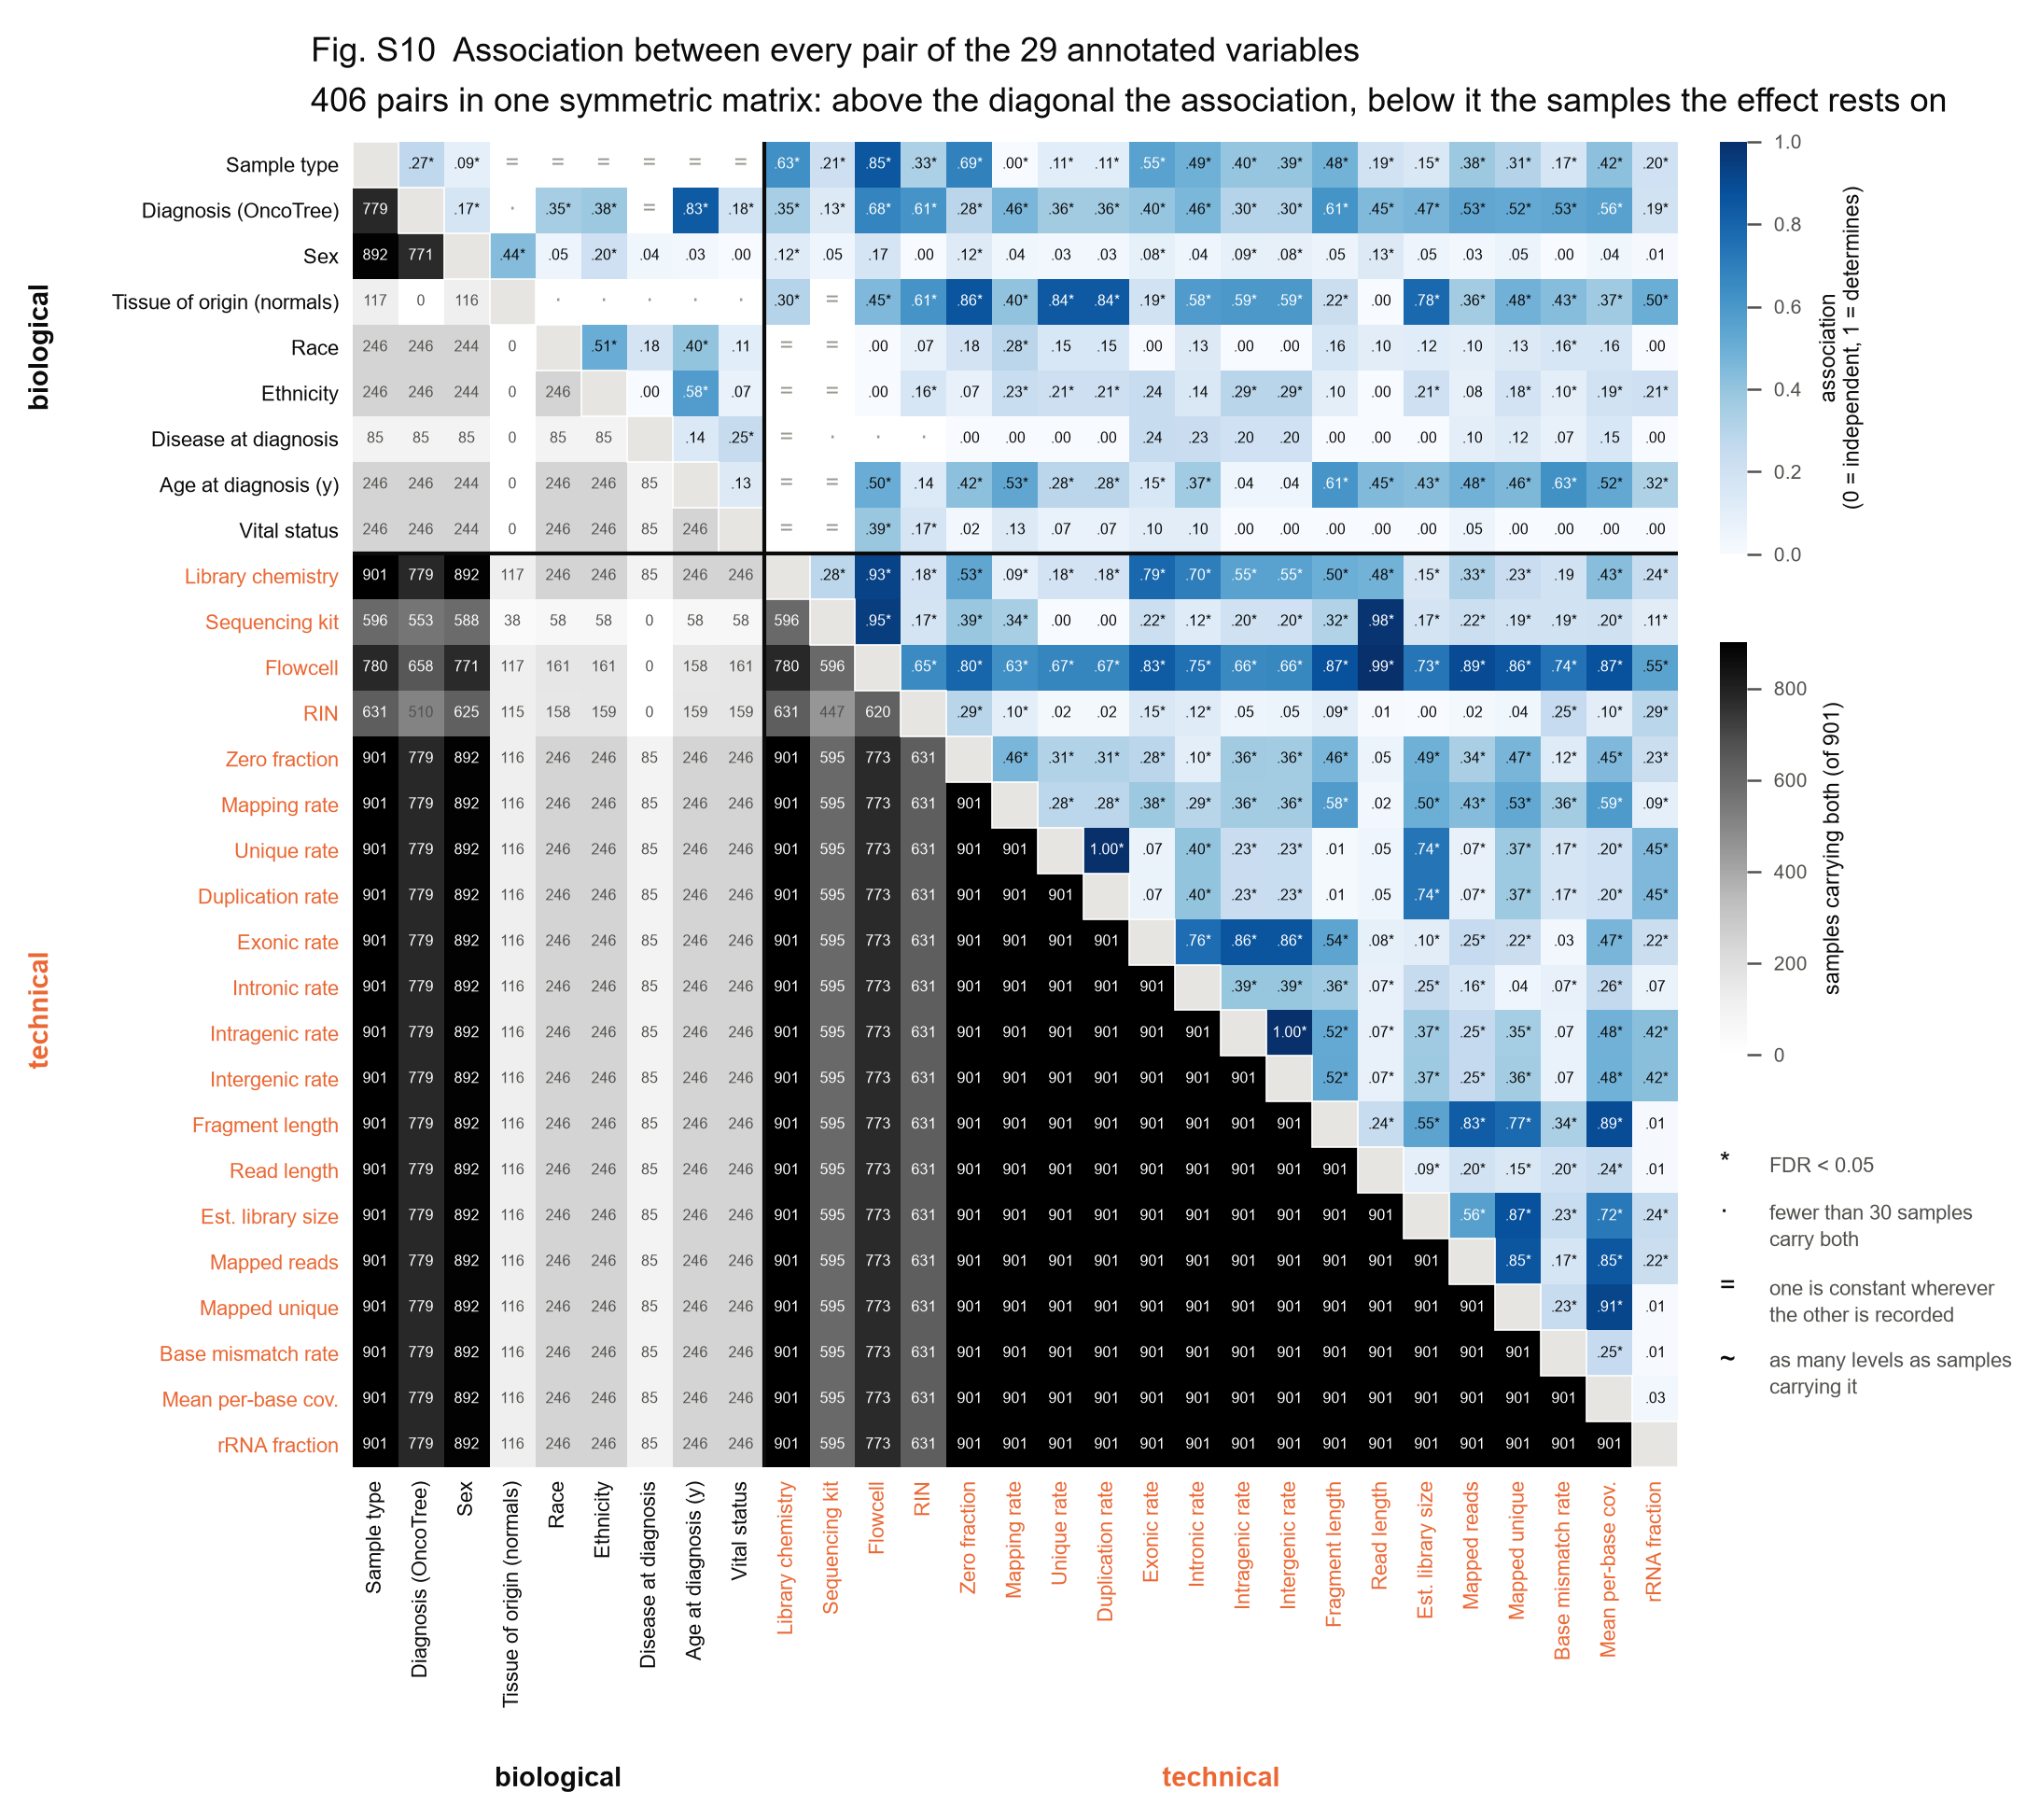

`submission/figures/figS11_confounding.png`

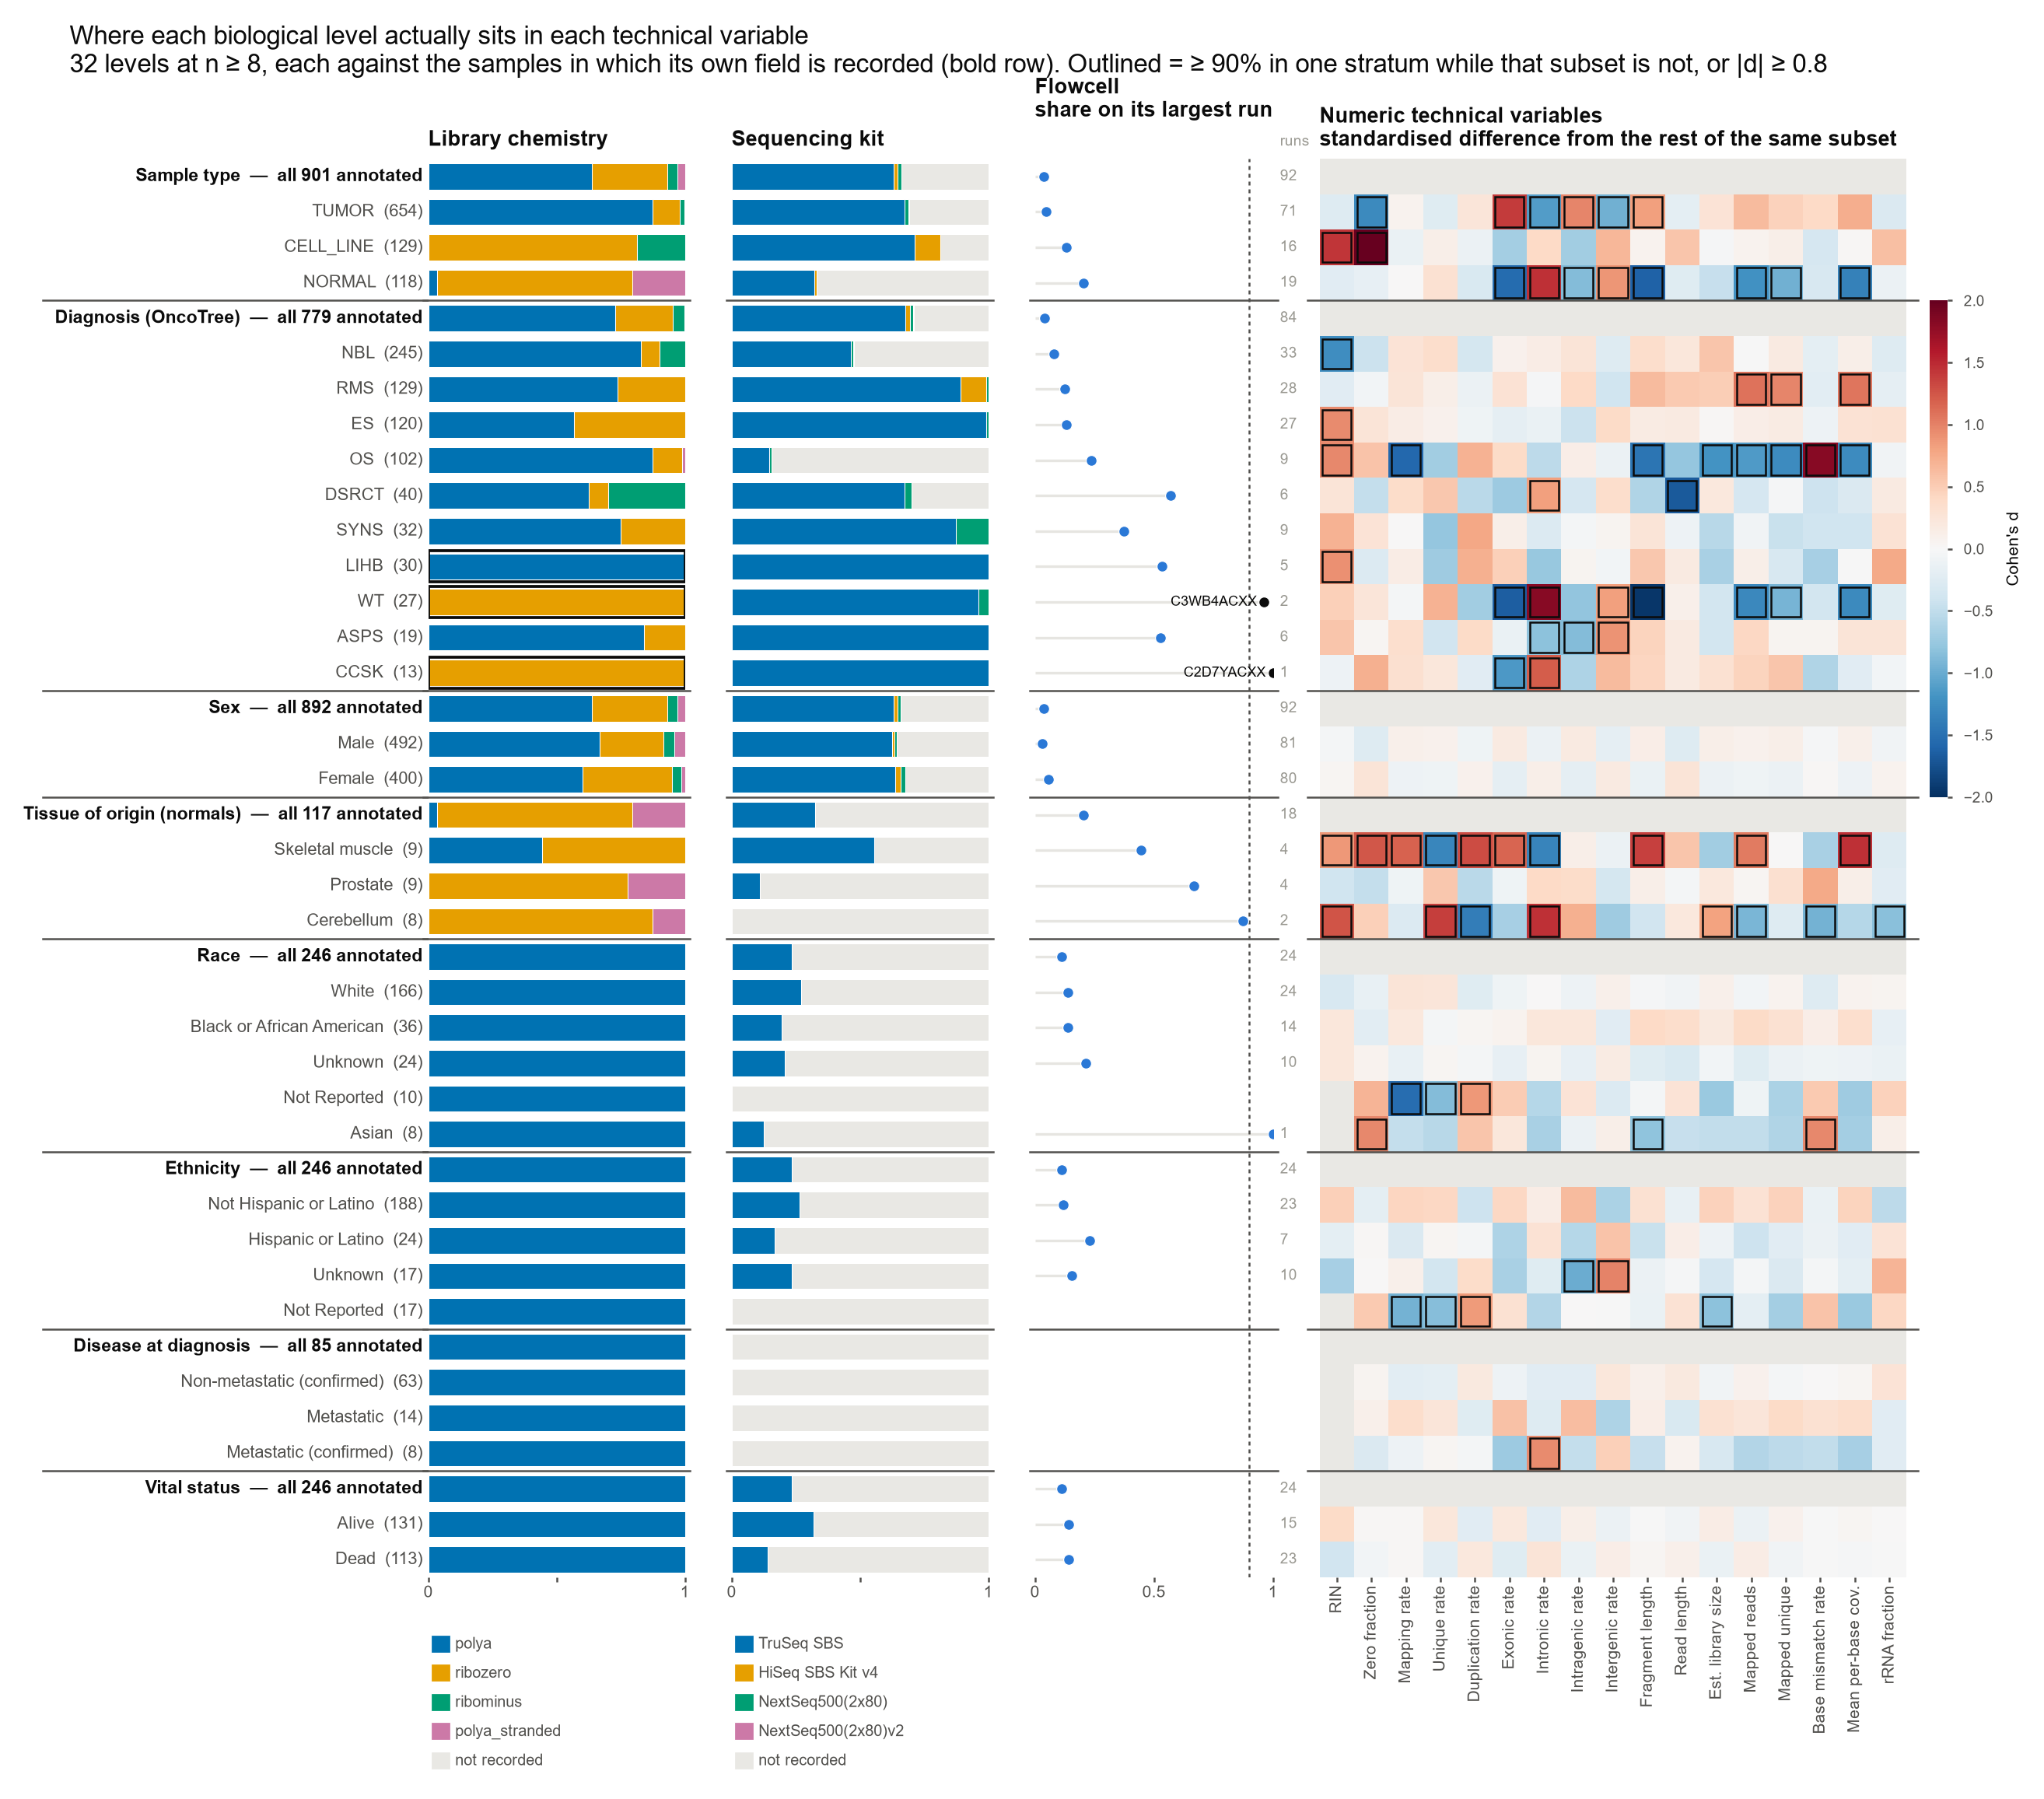

`submission/figures/figS12_limma_parity.png`

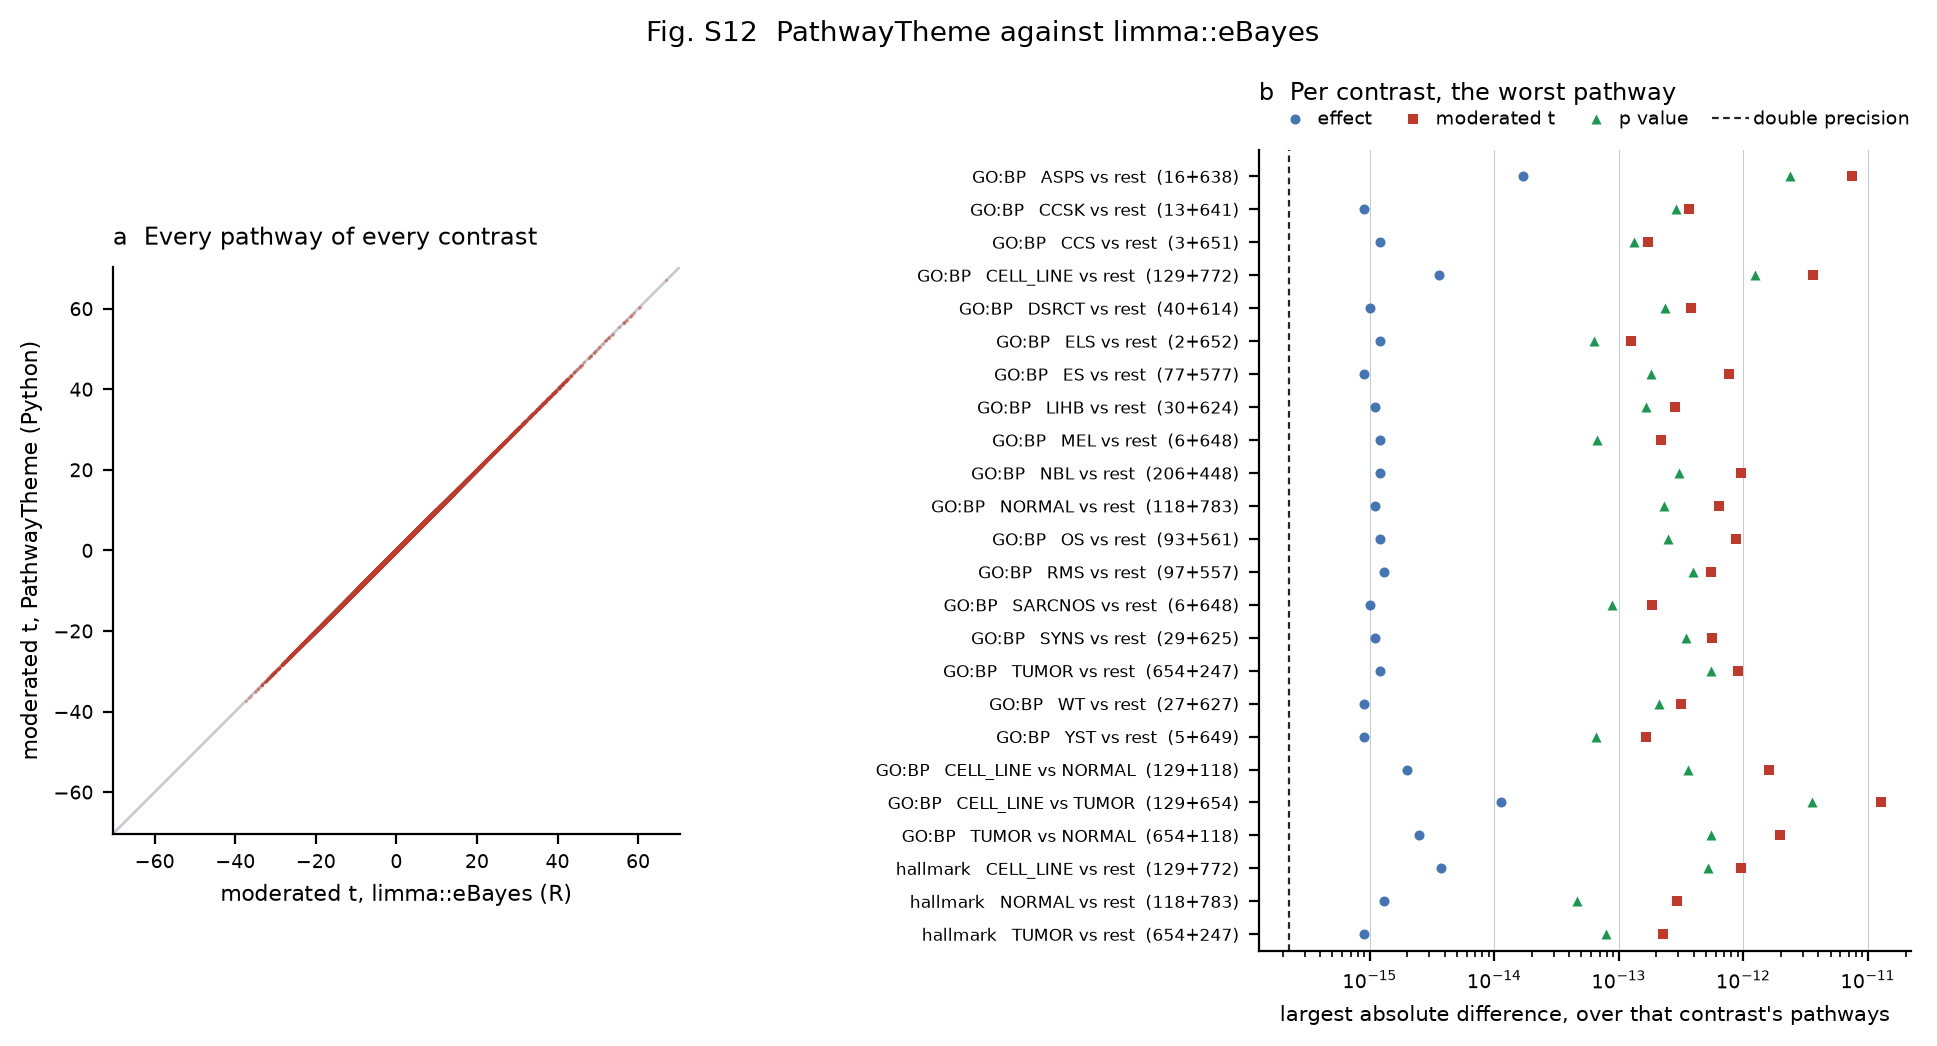

`submission/figures/figS1_pc_loadings.png`

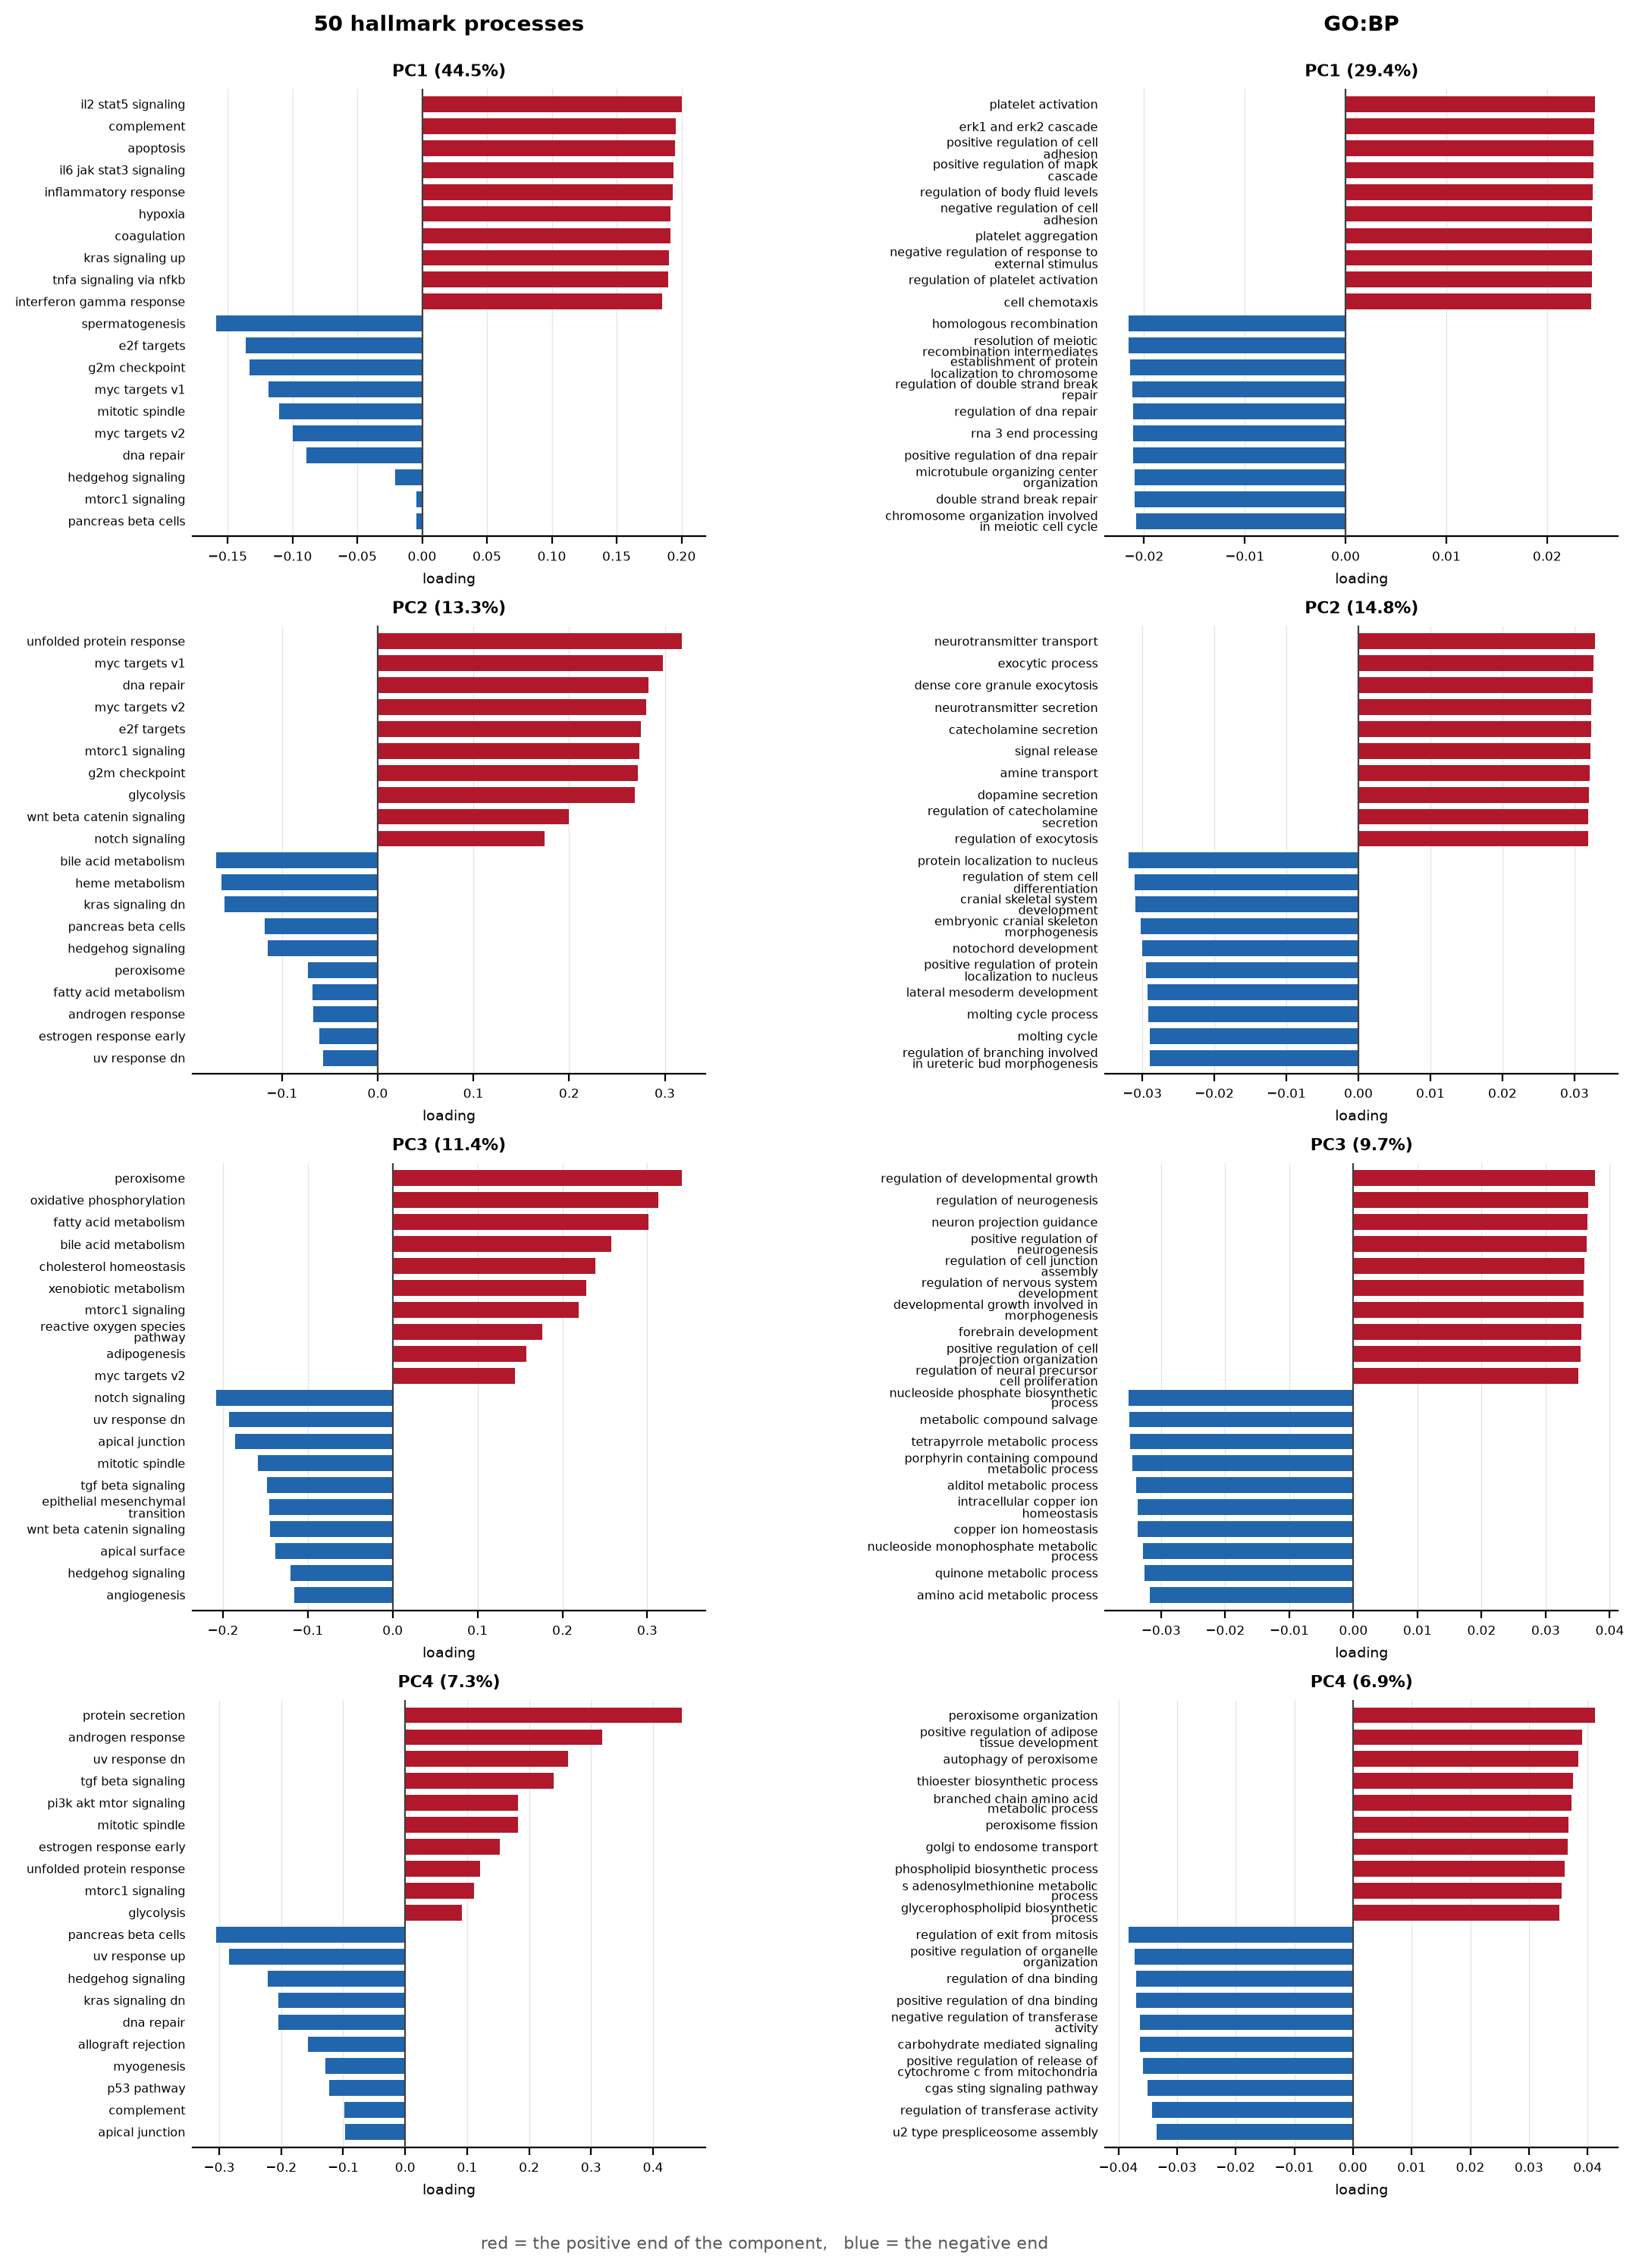

`submission/figures/figS2_pc_loadings_clustermap.png`

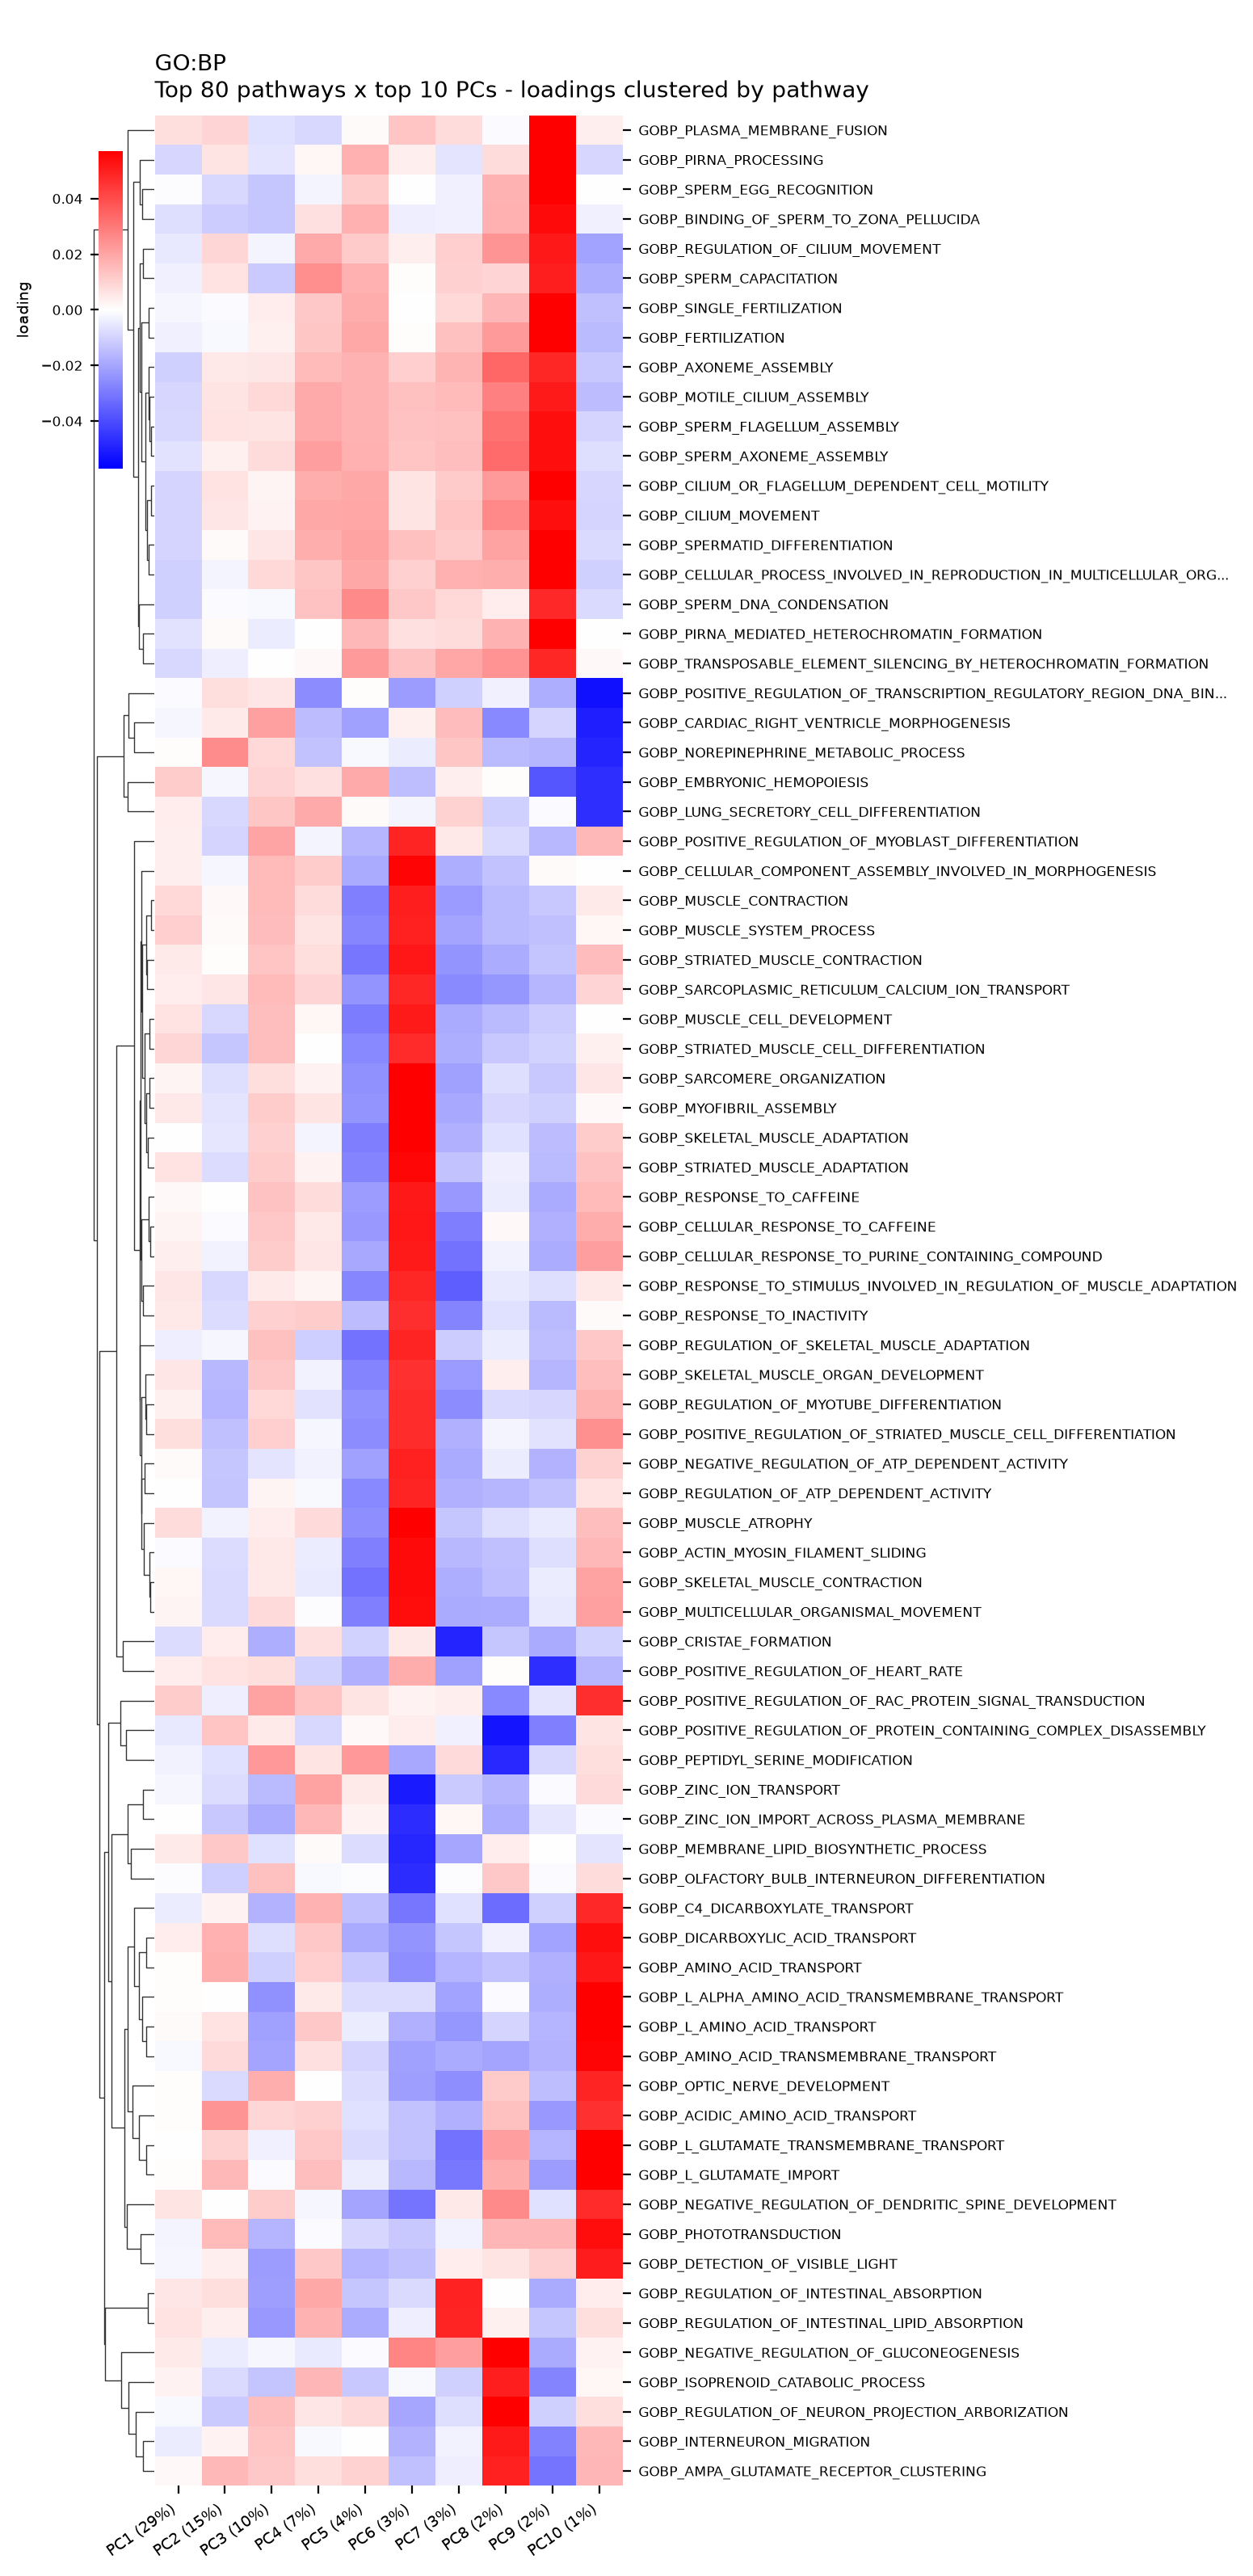

`submission/figures/figS3_pc_pairs.png`

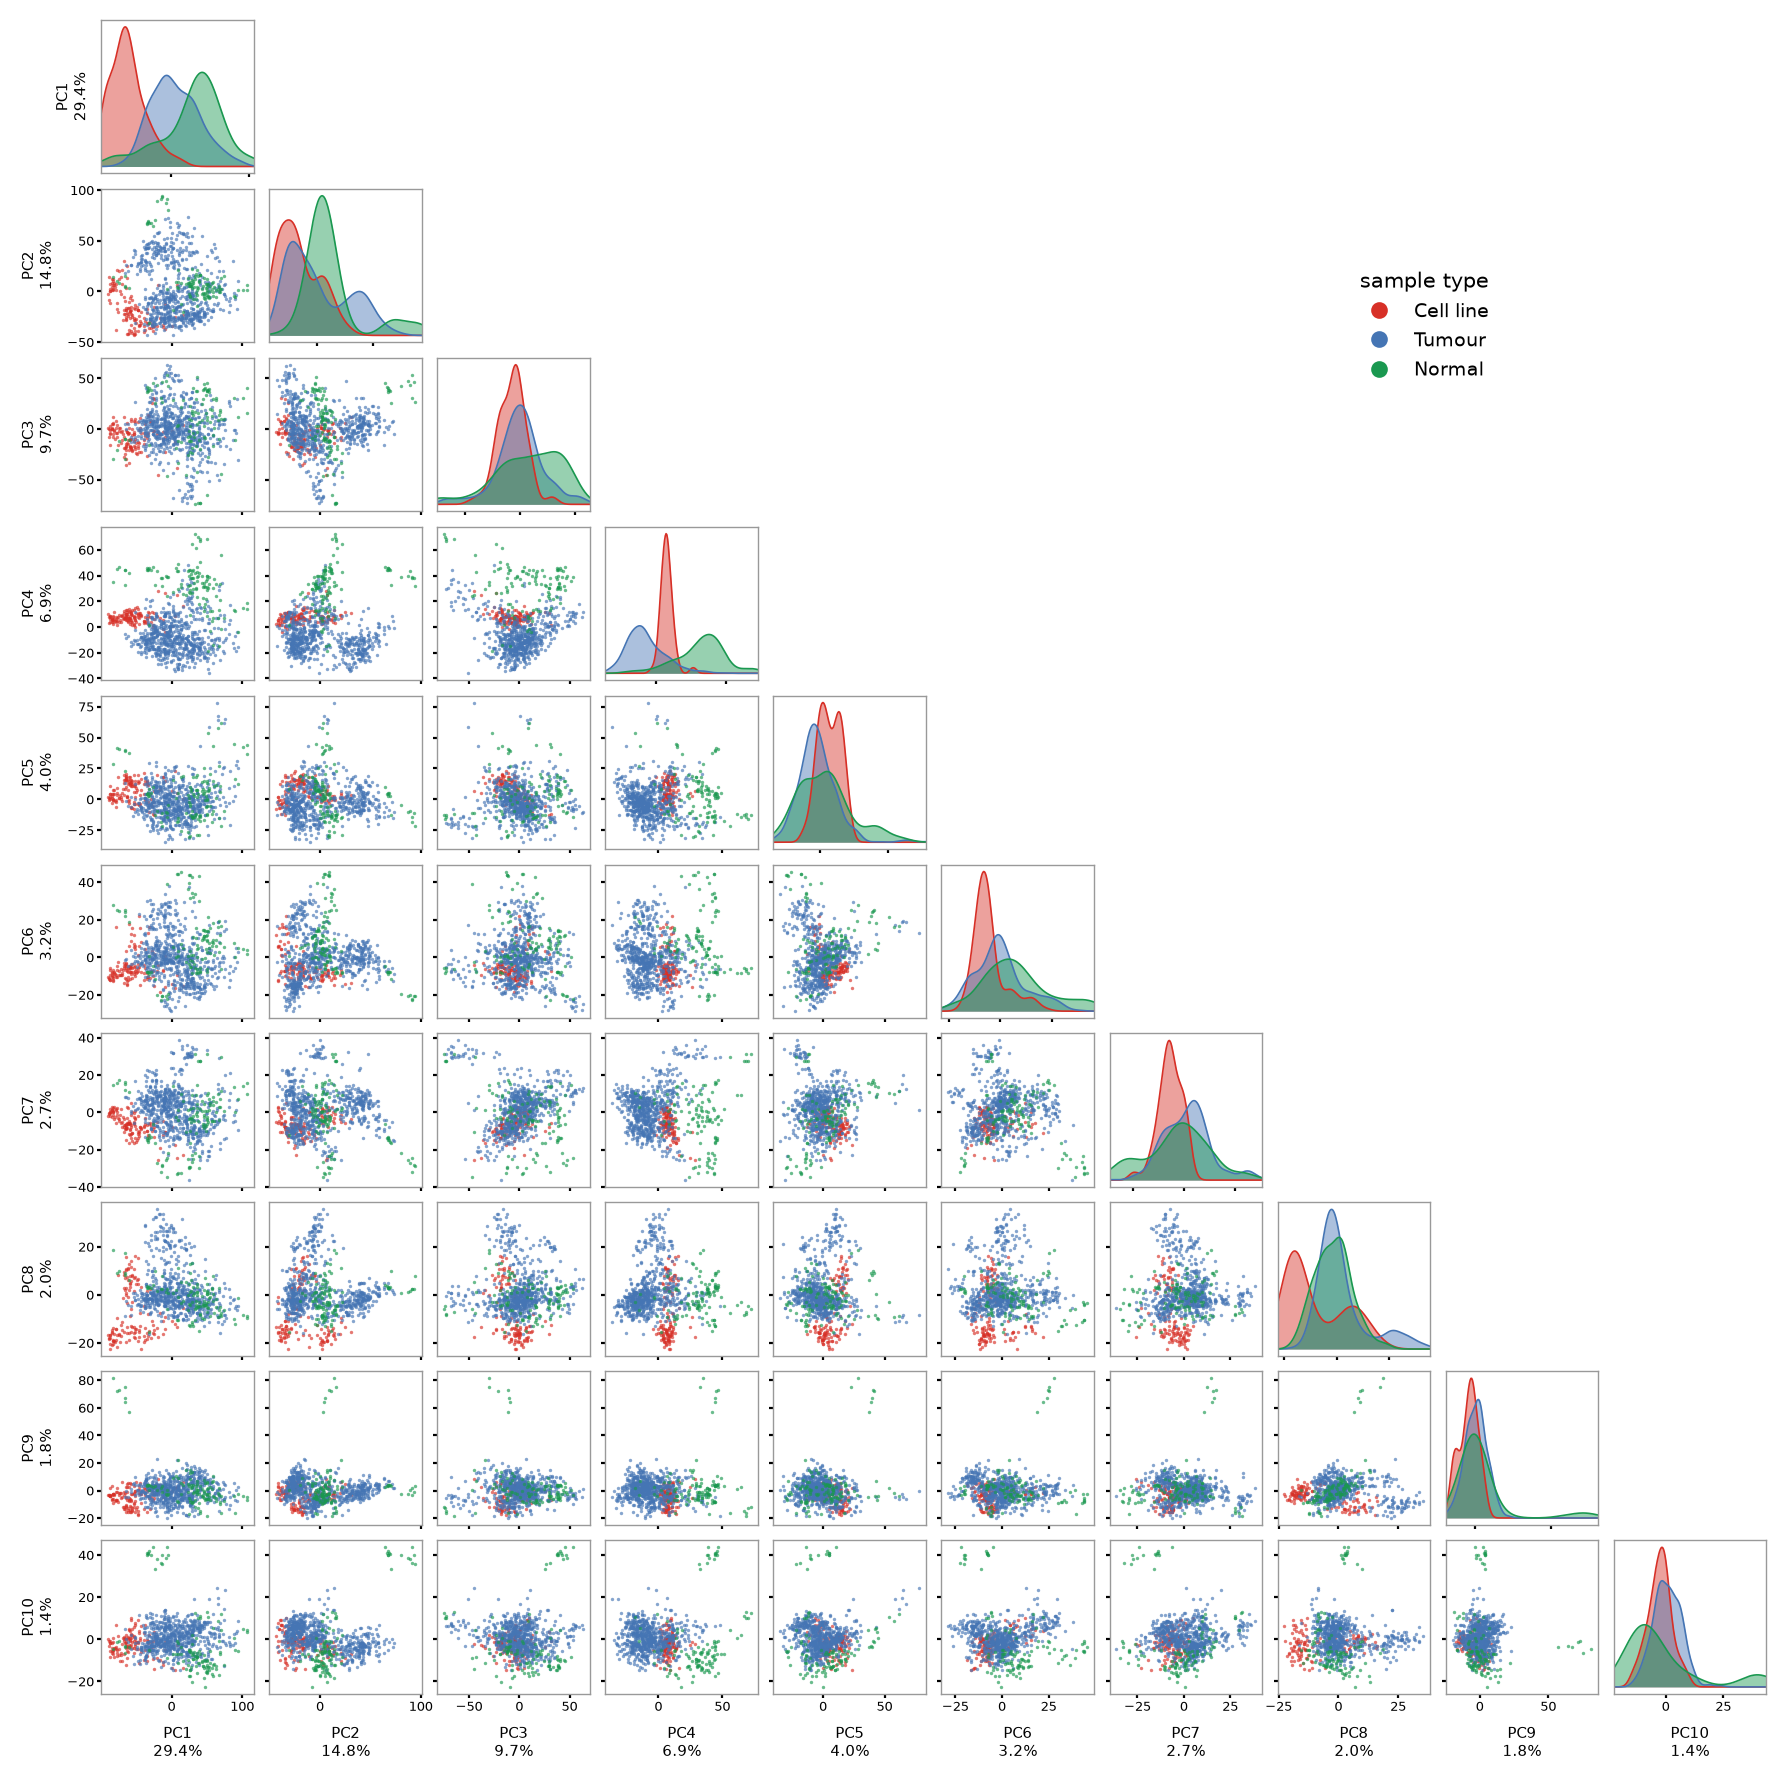

In [4]:
from analysis import components

fits = components.refit_all()
components.table_s15(fits)
components.figure_s1(fits);  nb.show_figure("figS1")
components.figure_s2(fits);  nb.show_figure("figS2")
components.figure_s3(fits);  nb.show_figure("figS3")
components.pc_pairs_by_diagnosis(fits);   # per-diagnosis panels for figures/raw

**One-vs-rest separation of each diagnosis (Fig. S4, Table S12).**

   tableS12: of 10 diagnoses at n >= 10, 7 separated at >= 0.9 and 2 partially (0.75-0.9) by a single component


**Table S12** — 14 rows × 16 columns

,gobp_PC1_auc,gobp_PC2_auc,gobp_PC3_auc,gobp_PC4_auc,gobp_PC5_auc,gobp_PC6_auc,gobp_PC7_auc,gobp_PC8_auc,gobp_PC9_auc,gobp_PC10_auc,n,best_pathway_pc,best_pathway_auc,separation,best_pathway_fdr,hallmark_separation
diagnosis,,,,,,,,,,,,,,,,
CCSK,0.499597,0.104209,0.997886,0.861257,0.351087,0.003021,0.854813,0.743858,0.369613,0.770741,13,PC3,0.997886,0.997886,2.976843e-09,0.984495
ASPS,0.839050,0.690043,0.066796,0.838425,0.460353,0.637481,0.020761,0.310026,0.656645,0.376684,19,PC7,0.020761,0.979239,5.125890e-12,0.914665
NBL,0.372833,0.979101,0.593670,0.305125,0.519833,0.502002,0.638990,0.343417,0.469840,0.178602,245,PC2,0.979101,0.979101,5.574346e-100,0.845197
LIHB,0.771397,0.565863,0.058947,0.931905,0.076528,0.309772,0.972155,0.544712,0.304016,0.747970,30,PC7,0.972155,0.972155,1.666912e-17,0.961847
WT,0.380198,0.104148,0.963753,0.763407,0.707556,0.542370,0.915259,0.425037,0.559062,0.492691,27,PC3,0.963753,0.963753,1.761120e-15,0.945284
YST,0.631088,0.201295,0.297668,0.811917,0.195855,0.114249,0.951813,0.412694,0.361658,0.649741,5,PC7,0.951813,0.951813,4.006812e-05,0.858549
ES,0.319990,0.472336,0.231621,0.645015,0.835439,0.532801,0.228869,0.929769,0.084944,0.481900,120,PC8,0.929769,0.929769,3.080327e-49,0.811086
RMS,0.380682,0.202735,0.643339,0.431596,0.214506,0.907754,0.528687,0.427577,0.524404,0.790889,129,PC6,0.907754,0.907754,4.603053e-47,0.880958
MEL,0.723303,0.618893,0.244055,0.787505,0.871379,0.557501,0.110030,0.424773,0.640510,0.610030,6,PC7,0.110030,0.889970,5.499192e-04,0.911371


   figS4: 7 diagnoses drawn in panel b


`submission/figures/figS4_diagnosis_pc.png`

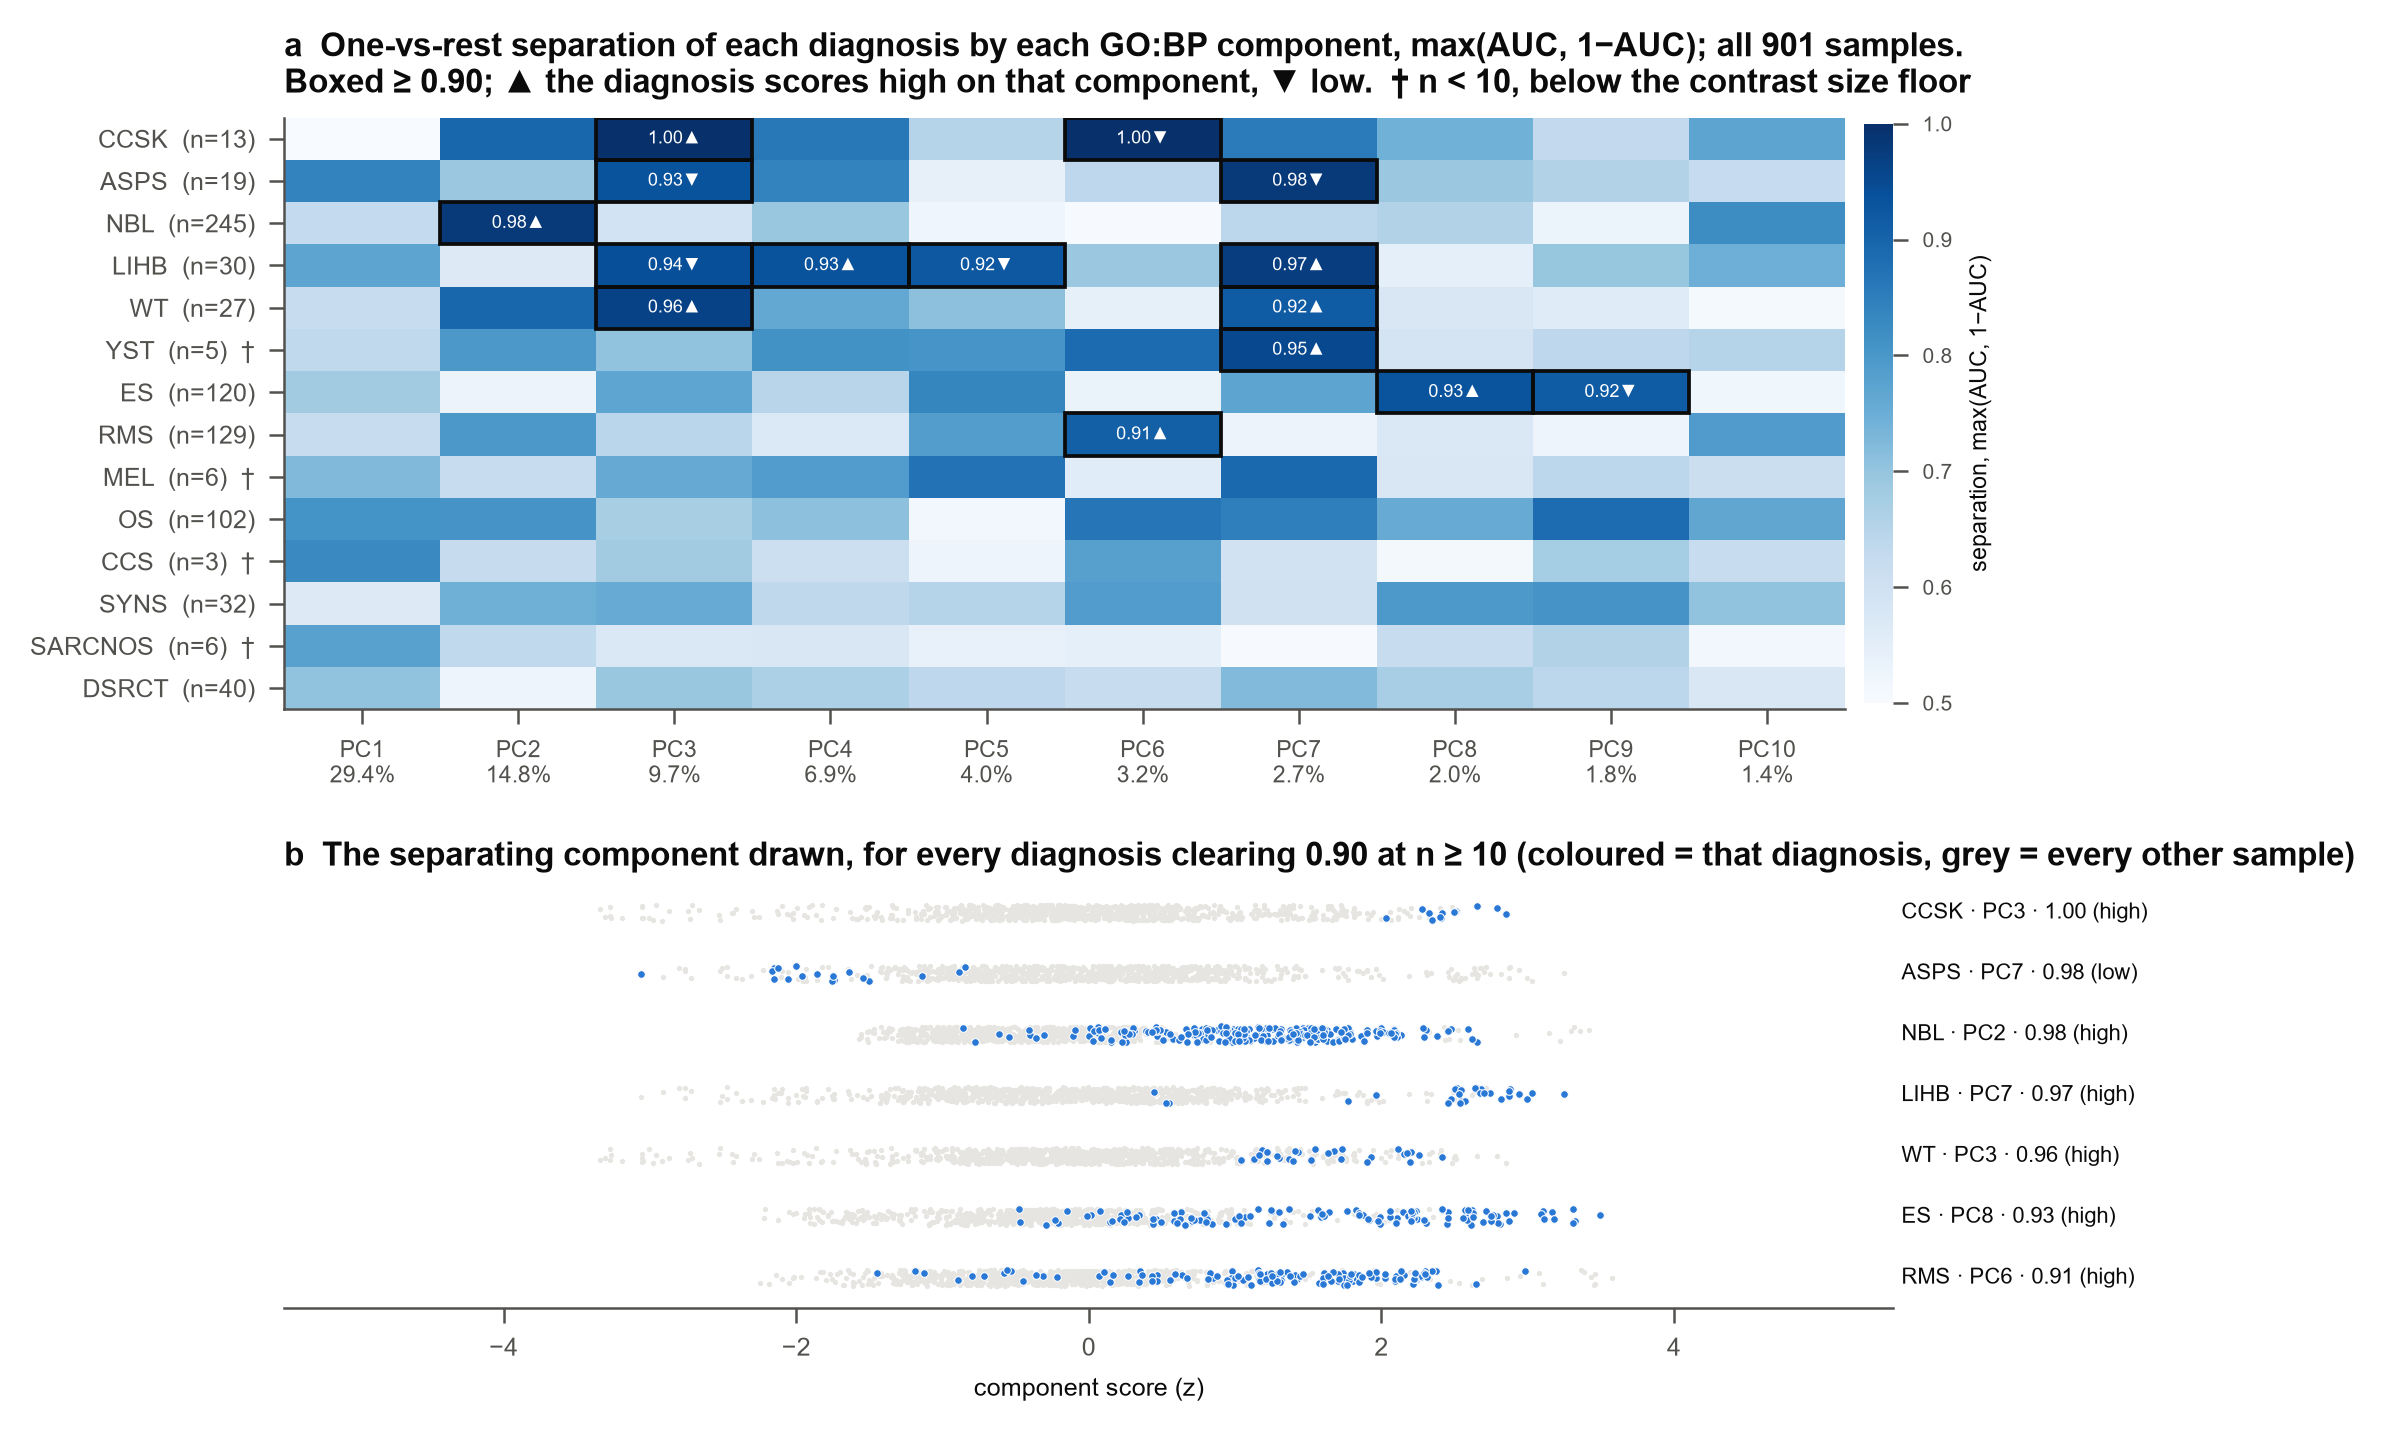

In [5]:
from analysis import annotation

nb.show_table(annotation.table_s12(), name="Table S12")
annotation.figure_s4();  nb.show_figure("figS4")